# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

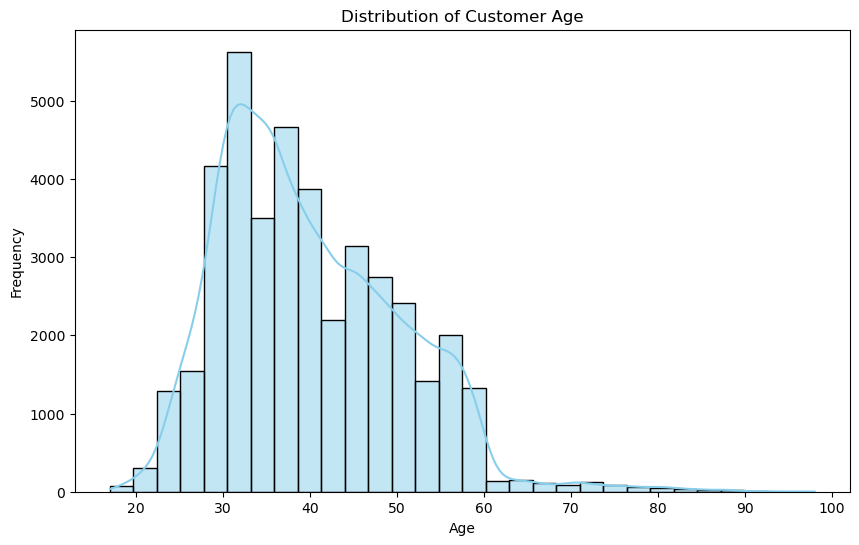

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

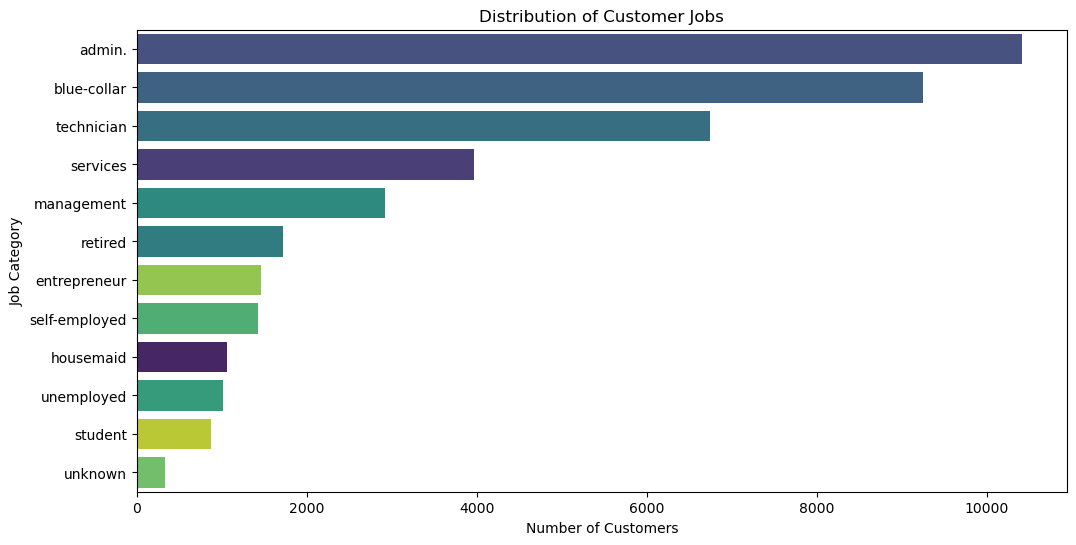

In [6]:

plt.figure(figsize=(12, 6))
sns.countplot(
    y='job', 
    data=df, 
    order=df['job'].value_counts().index, 
    hue='job',          
    palette='viridis', 
    legend=False        
)
plt.title('Distribution of Customer Jobs')
plt.xlabel('Number of Customers')
plt.ylabel('Job Category')
plt.show()

## Balance & Deposit Trends

Average Call Duration by Subscription Status:
y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


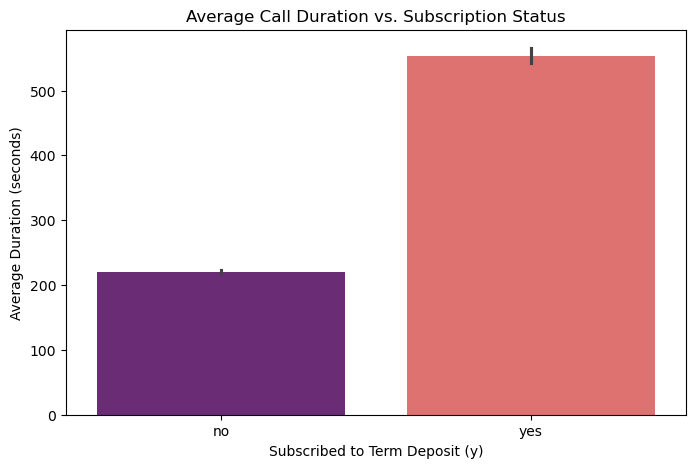

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_duration = df.groupby('y')['duration'].mean()

print("Average Call Duration by Subscription Status:")
print(avg_duration)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='y', 
    y='duration', 
    data=df, 
    hue='y', 
    palette='magma', 
    legend=False
)

plt.title('Average Call Duration vs. Subscription Status')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Average Duration (seconds)')
plt.show()

## Campaign Effectiveness

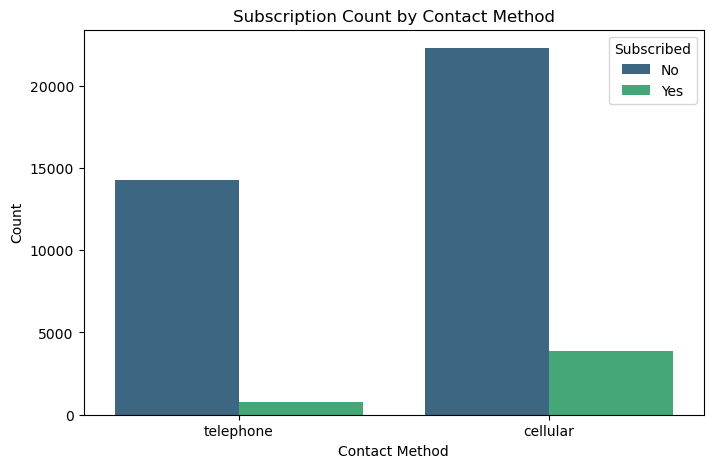

Subscription Success Rate (%) per Contact Method:
y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='contact', hue='y', data=df, palette='viridis')
plt.title('Subscription Count by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Count')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.show()

contact_success = df.groupby('contact')['y'].value_counts(normalize=True).unstack() * 100
print("Subscription Success Rate (%) per Contact Method:")
print(contact_success)

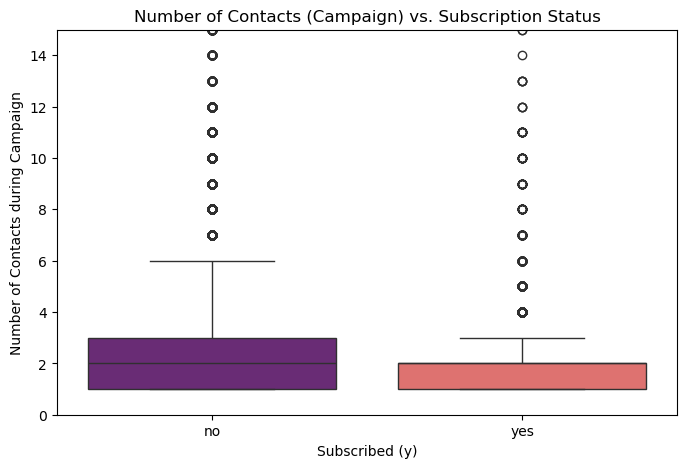

Average Number of Contacts by Subscription:
y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64


In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='campaign', data=df, hue='y', palette='magma', legend=False)

plt.ylim(0, 15) 
plt.title('Number of Contacts (Campaign) vs. Subscription Status')
plt.xlabel('Subscribed (y)')
plt.ylabel('Number of Contacts during Campaign')
plt.show()

print("Average Number of Contacts by Subscription:")
print(df.groupby('y')['campaign'].mean())

## Correlation Heatmap

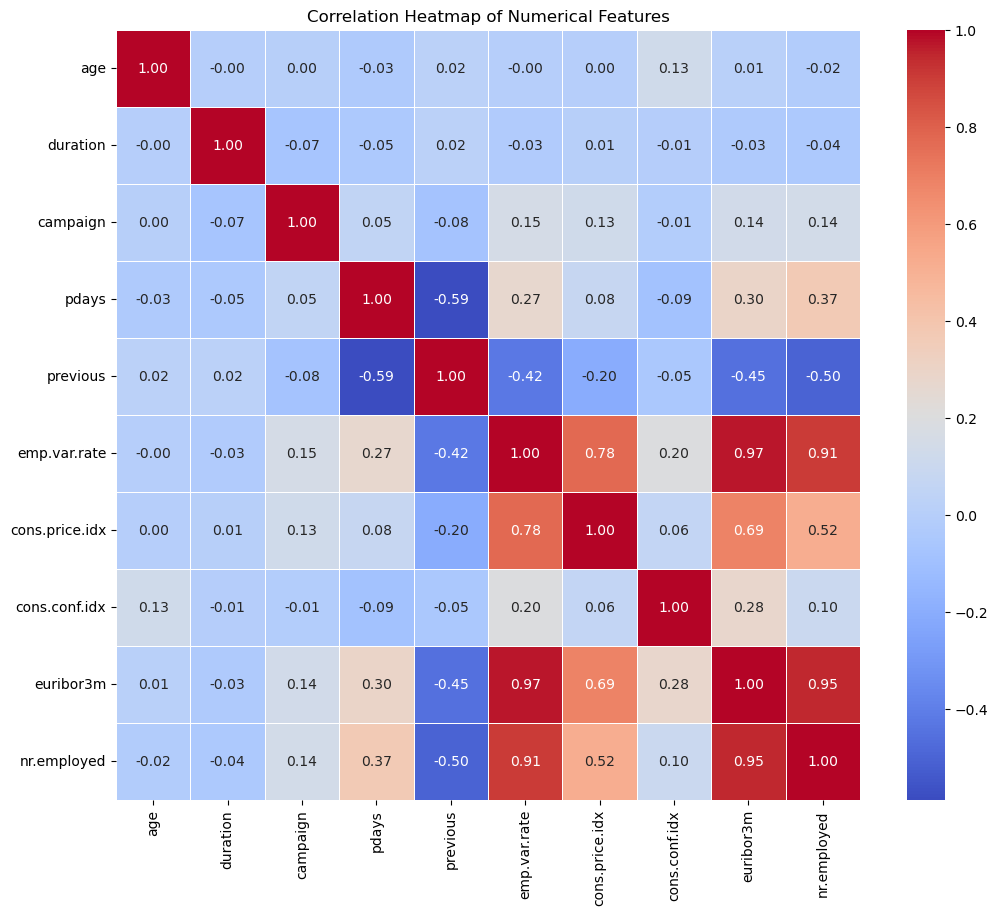

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Predictive Modeling (Logistic Regression)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

df_model = df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



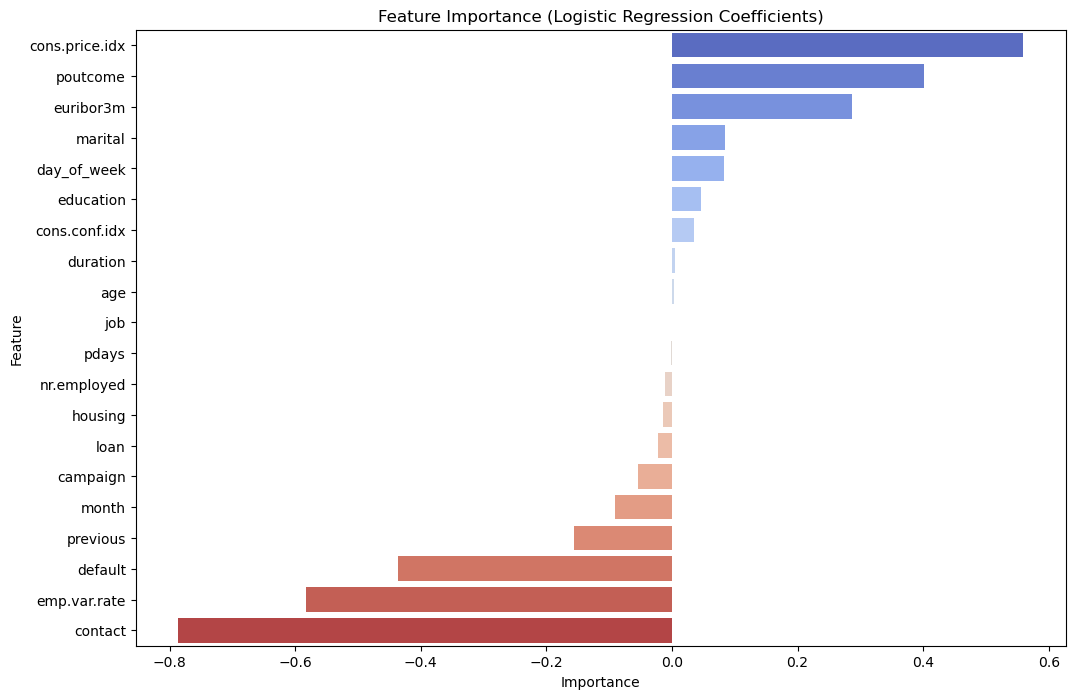

In [17]:
import pandas as pd

importance = model.coef_[0]
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.